In [1]:
import matplotlib.pyplot as plt

In [2]:
# ncut values for each algorithm
louvain_ncut = [1.01, 1.19, 1.08, 2.01, 1.23, 1.55, 0.98]
dbscan_ncut = [0.0, 0.0, 80.95, 6.1, 87.0, 87.0, 10.17]
spectral_ncut = [0.1, 0.0, 0.05, 0.16, 0.08, 0.11, 0.3]

# rcut values for each algorithm
louvain_rcut = [0.11, 0.38, 0.85, 1.46, 2.45, 5.56, 0.85]
dbscan_rcut = [0.0, 0.0, 84.61, 6.39, 221.34, 361.01, 13.78]
spectral_rcut = [0.02, 0.0, 0.04, 0.1, 0.17, 0.39, 0.23]

# modularity values for each algorithm
louvain_modularity = [0.38, 0.53, 0.58, 0.45, 0.57, 0.53, 0.36]
dbscan_modularity = [-0.0, 0.0, -0.01, -0.0, -0.01, -0.01, 0.0]
spectral_modularity = [0.37, 0.47, 0.44, 0.4, 0.42, 0.4, 0.34]

# CC values for each algorithm
louvain_CC = [29, 2, 1, 1, 1, 1, 1]
dbscan_CC = [29, 2, 1, 1, 1, 1, 1]
spectral_CC = [29, 2, 1, 1, 1, 1, 1]

# nCluster values for each algorithm
louvain_nCluster = [32, 7, 5, 5, 5, 5, 3]
dbscan_nCluster = [1, 1, 81, 7, 87, 87, 11]
spectral_nCluster = [2, 2, 2, 2, 2, 2, 2]

# rho values (for reference)
rho_values = [0.9, 0.5, 0.2, 0.1, 0.09, 0.05, 0.01]

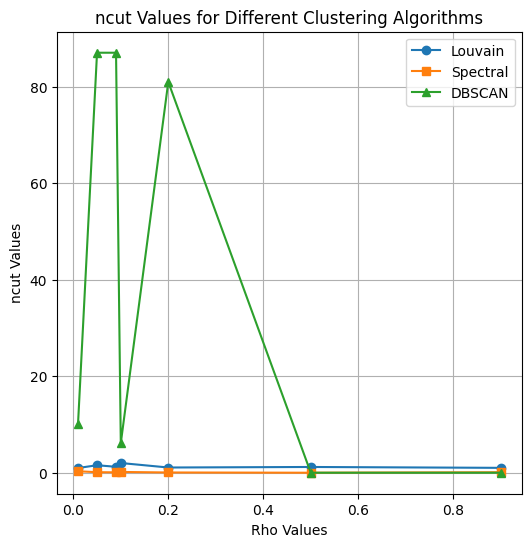

In [7]:
# Create the plot
plt.figure(figsize=(6, 6))

plt.plot(rho_values, louvain_ncut, 'o-', label='Louvain')
plt.plot(rho_values, spectral_ncut, 's-', label='Spectral')
plt.plot(rho_values, dbscan_ncut, '^-', label='DBSCAN')

plt.xlabel('Reg. Parameter (λ)')
plt.ylabel('N Cut')
plt.title('ncut Values for Different Clustering Algorithms')
plt.grid(True)
plt.legend()
plt.show()

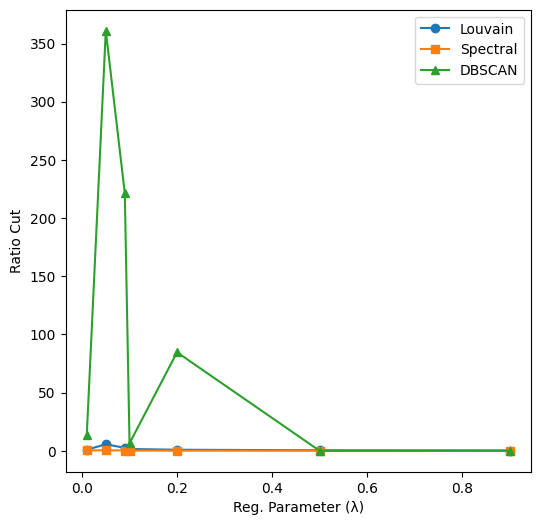

In [18]:
# Create the plot
plt.figure(figsize=(6, 6))

plt.plot(rho_values, louvain_rcut, 'o-', label='Louvain')
plt.plot(rho_values, spectral_rcut, 's-', label='Spectral')
plt.plot(rho_values, dbscan_rcut, '^-', label='DBSCAN')

plt.xlabel('Reg. Parameter (λ)')
plt.ylabel('Ratio Cut')
plt.legend()
plt.show()

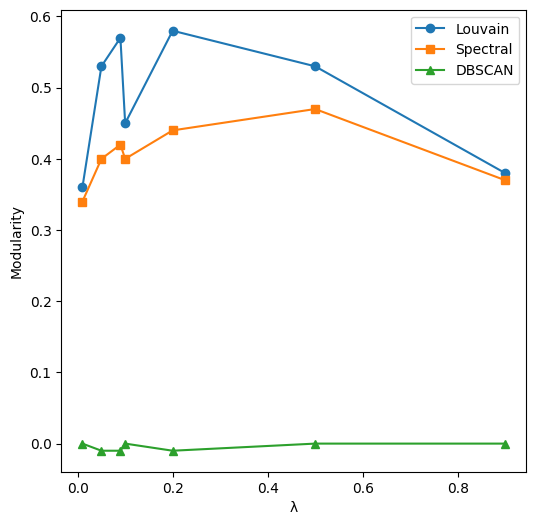

In [13]:
# Create the plot
plt.figure(figsize=(6, 6))

plt.plot(rho_values, louvain_modularity, 'o-', label='Louvain')
plt.plot(rho_values, spectral_modularity, 's-', label='Spectral')
plt.plot(rho_values, dbscan_modularity, '^-', label='DBSCAN')

plt.xlabel('Reg. Parameter (λ)')
plt.ylabel('Modularity')
plt.legend()
plt.show()

In [ ]:
def extract_results(metrics):
    # Initialize the rho_values list and dictionaries for each algorithm and metric
    rho_values = sorted(list(metrics.keys()), reverse=True)
    
    # Initialize empty lists for each algorithm and metric
    lists_dict = {
        'rho_values': rho_values,
        'louvain_ncut': [],
        'dbscan_ncut': [],
        'spectral_ncut': [],
        'louvain_rcut': [],
        'dbscan_rcut': [],
        'spectral_rcut': [],
        'louvain_modularity': [],
        'dbscan_modularity': [],
        'spectral_modularity': [],
        'louvain_CC': [],
        'dbscan_CC': [],
        'spectral_CC': [],
        'louvain_nCluster': [],
        'dbscan_nCluster': [],
        'spectral_nCluster': []
    }
    
    # Extract values for each rho value
    for rho in rho_values:
        for algorithm in ['louvain', 'dbscan', 'spectral']:
            if algorithm in metrics[rho]:
                result = metrics[rho][algorithm]
                for metric in ['ncut', 'rcut', 'modularity', 'CC', 'nCluster']:
                    if metric in result:
                        lists_dict[f'{algorithm}_{metric}'].append(result[metric])
                    else:
                        lists_dict[f'{algorithm}_{metric}'].append(None)  # Handle missing metrics
            else:
                # Handle case where an algorithm is missing for a rho value
                for metric in ['ncut', 'rcut', 'modularity', 'CC', 'nCluster']:
                    lists_dict[f'{algorithm}_{metric}'].append(None)
    
    return lists_dict